# Marta Negri
# Luca Davì

## Taks 2:
assessing the performance of pre-trained models in a zero-shot setting, where no additional training on waste images is performed. This will provide insights
into the generalization capabilities of modern detectors such as YOLO, DETR, and RT-DETR.
After the initial evaluation, fine-tune a small variant of the RT-DETR model on the training split
of the waste images dataset, and assess and discuss its performance, comparing it to the other
models

notes for mac users: We had to switch to colab because of an unimplemented function in the trainer that forced the fall back to cpu, this meant that each training epoch would take 5 minutes, making training impossible

In [1]:
!pip install -q gdown
#https://drive.google.com/file/d/1e4tsIf_jCotS91V-5BDJH-gEPphQDydz/view?usp=share_link
#https://drive.google.com/file/d/1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv/view?usp=share_link
FILE_ID = "1e4tsIf_jCotS91V-5BDJH-gEPphQDydz" #dataset
!gdown --id $FILE_ID -O /content/data.zip
FILE_ID = "1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv" #library
!gdown --id $FILE_ID -O /content/taco_dataset.py

!unzip -oq /content/data.zip -d /content/taco_subset



/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1e4tsIf_jCotS91V-5BDJH-gEPphQDydz
From (redirected): https://drive.google.com/uc?id=1e4tsIf_jCotS91V-5BDJH-gEPphQDydz&confirm=t&uuid=64c0d844-a202-4d5f-a75e-20bc74015ab2
To: /content/data.zip
100% 1.12G/1.12G [00:16<00:00, 66.0MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv
From (redirected): https://drive.google.com/uc?id=1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv&confirm=t&uuid=c751aaa3-30cc-4e4c-a3e7-9889ec130317
To: /content/taco_dataset.py


### 2.1 Dataset Preparation

In [2]:
%pip install pycocotools ultralytics torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 16.4 MB/s eta 0:00:00


In [3]:
import os

os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torchvision
import torch
import matplotlib.pyplot as plt
import numpy as np


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [6]:

#######################################LOCAL PATH###############################
# root = './data/TACO_subset'
# train_ann='./data/TACO_subset/annotations_train.json'
################################################################################
#######################################COLAB PATH###############################
root = '/content/taco_subset/data/TACO_subset'
################################################################################
#Annotation path is constructed based on root path, no need to specify it
train_dataset = torchvision.datasets.CocoDetection(root=root, annFile=root+'/annotations_train.json', transform=None)
test_dataset = torchvision.datasets.CocoDetection(root=root, annFile=root+'/annotations_test.json', transform=None)
val_dataset = torchvision.datasets.CocoDetection(root=root, annFile=root+'/annotations_val.json', transform=None)
#yolo and detr require images in different formats with different pipelines

train_dataset[0]

loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


(<PIL.Image.Image image mode=RGB size=768x1024>,
 [{'id': 1,
   'image_id': 0,
   'category_id': 2,
   'segmentation': [[280.3175016265452,
     618.6979014153246,
     283.8152244632401,
     600.2069302098585,
     283.31554977228365,
     587.2132747681796,
     274.32140533506833,
     563.2249877989263,
     268.8249837345478,
     544.2342606149341,
     259.33116460637603,
     521.2454856027331,
     258.33181522446324,
     502.25475841874083,
     261.3298633702017,
     481.76476329917034,
     264.3279115159402,
     472.2693997071742,
     259.8308392973325,
     447.78135675939484,
     262.32921275211453,
     430.7896534895071,
     267.825634352635,
     410.29965836993654,
     276.8197787898504,
     384.3123474865788,
     288.3122966818478,
     363.3225963884822,
     297.3064411190631,
     338.8345534407028,
     297.80611581001955,
     292.3572474377745,
     293.80871828236826,
     172.91556857003417,
     290.31099544567337,
     163.91996095656418,
     28

In [7]:
train_length = len(train_dataset)
test_length = len(test_dataset)
val_length = len(val_dataset)
tot_length = train_length + test_length + val_length

print(f"Train dataset length: {train_length}: {train_length/tot_length*100:.2f}% of total")
print(f"Test dataset length: {test_length}: {test_length/tot_length*100:.2f}% of total")
print(f"Validation dataset length: {val_length}: {val_length/tot_length*100:.2f}% of total")

Train dataset length: 799: 69.66% of total
Test dataset length: 178: 15.52% of total
Validation dataset length: 170: 14.82% of total


In [8]:
# Class statistics per split (using COCO JSON files)
from pycocotools.coco import COCO
from collections import Counter
import pandas as pd

def coco_class_stats_from_file(ann_file, split_name):
    """
    Compute number of instances per category
    Returns a DataFrame with columns:
    [split, category_id, category_name, num_instances]
    """
    coco = COCO(ann_file)

    # All category IDs and names
    cat_ids = coco.getCatIds()
    cat_id_to_name = {c['id']: c['name'] for c in coco.loadCats(cat_ids)}

    # All annotations in this split
    ann_ids = coco.getAnnIds()
    anns = coco.loadAnns(ann_ids)

    # Count category occurrences
    counter = Counter([ann['category_id'] for ann in anns])

    rows = []
    for cid in cat_ids:
        rows.append({
            "split": split_name,
            "category_id": cid,
            "category_name": cat_id_to_name[cid],
            "num_instances": counter.get(cid, 0),
        })

    return pd.DataFrame(rows)

# Use existing annotation paths
train_ann_file = root + "/annotations_train.json"
val_ann_file   = root + "/annotations_val.json"
test_ann_file  = root + "/annotations_test.json"

# Compute stats for each split
train_stats = coco_class_stats_from_file(train_ann_file, "train")
val_stats   = coco_class_stats_from_file(val_ann_file, "val")
test_stats  = coco_class_stats_from_file(test_ann_file, "test")

# Combine all into a single table
all_stats = pd.concat([train_stats, val_stats, test_stats], ignore_index=True)

print("Per-class instance counts per split:")
display(all_stats.sort_values(["category_name", "split"]).reset_index(drop=True))
 #aggregate total instances per class across all splits
total_per_class = (
    all_stats
    .groupby(["category_id", "category_name"])["num_instances"]
    .sum()
    .reset_index()
    .sort_values("num_instances", ascending=False)
)

print("Total instances per class (all splits combined):")
display(total_per_class)

# save to CSV
all_stats.to_csv("taco_class_stats_per_split.csv", index=False)
total_per_class.to_csv("taco_class_stats_total.csv", index=False)


loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Per-class instance counts per split:


,split,category_id,category_name,num_instances
0,test,2,Bottle,54
1,test,2,Bottle,54
2,test,2,Bottle,54
3,train,2,Bottle,314
4,train,2,Bottle,314
...,...,...,...,...
175,val,-1,Unlabeled litter,0
176,val,-1,Unlabeled litter,0
177,val,-1,Unlabeled litter,0
178,val,-1,Unlabeled litter,0


Total instances per class (all splits combined):


,category_id,category_name,num_instances
1,0,Plastic bag & wrapper,5950
6,5,Carton,1757
3,2,Bottle,1317
5,4,Can,819
2,1,Cigarette,667
4,3,Bottle cap,578
0,-1,Unlabeled litter,0


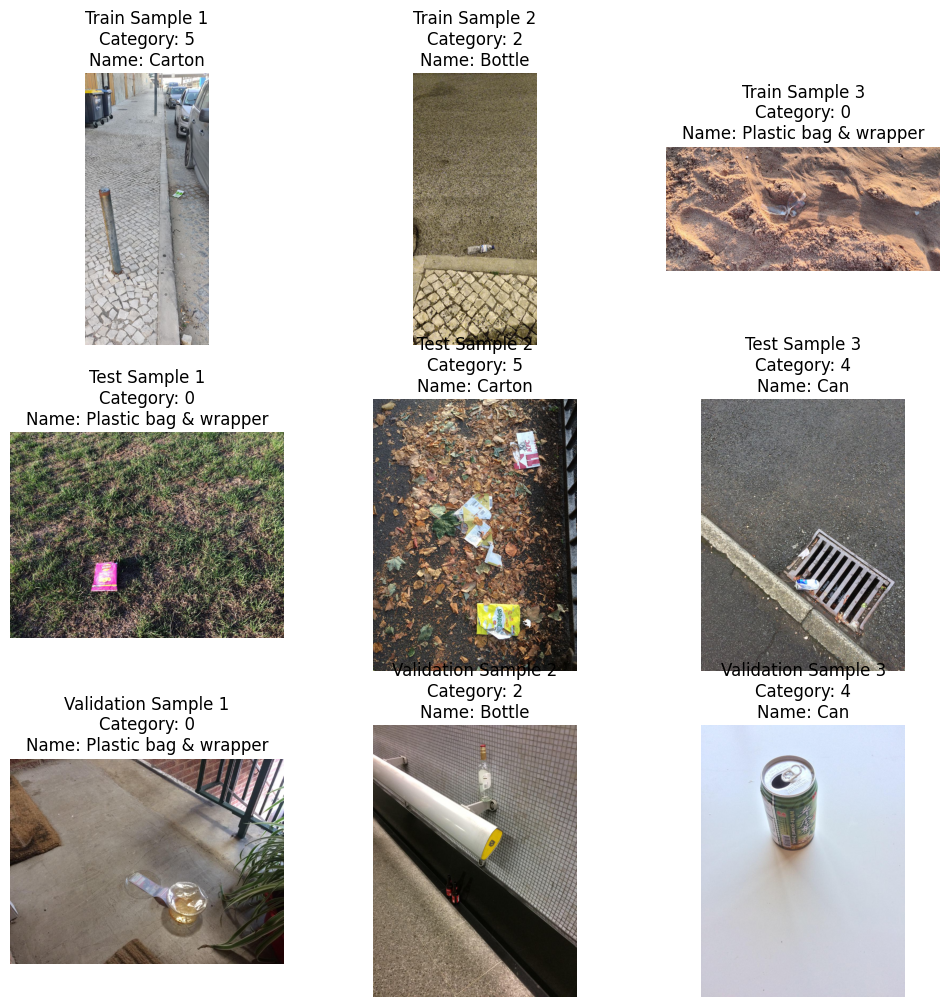

In [9]:
# Visualize three samples from each split with the corresponding category labels with category names

indexes = torch.randint(0, min(train_length, test_length, val_length), (3,)).tolist()

fig, axs = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    axs[0, i].imshow(train_dataset[indexes[i]][0])
    axs[0, i].set_title(f"Train Sample {i+1}\nCategory: {train_dataset[indexes[i]][1][0]['category_id']}\nName: {train_dataset.coco.loadCats(train_dataset[indexes[i]][1][0]['category_id'])[0]['name']}")
    axs[0, i].axis('off')

    axs[1, i].imshow(test_dataset[indexes[i]][0])
    axs[1, i].set_title(f"Test Sample {i+1}\nCategory: {test_dataset[indexes[i]][1][0]['category_id']}\nName: {test_dataset.coco.loadCats(test_dataset[indexes[i]][1][0]['category_id'])[0]['name']}")
    axs[1, i].axis('off')

    axs[2, i].imshow(val_dataset[indexes[i]][0])
    axs[2, i].set_title(f"Validation Sample {i+1}\nCategory: {val_dataset[indexes[i]][1][0]['category_id']}\nName: {val_dataset.coco.loadCats(val_dataset[indexes[i]][1][0]['category_id'])[0]['name']}")
    axs[2, i].axis('off')

The bar chart visualizes the class distribution, highlighting which waste categories are more or less frequent

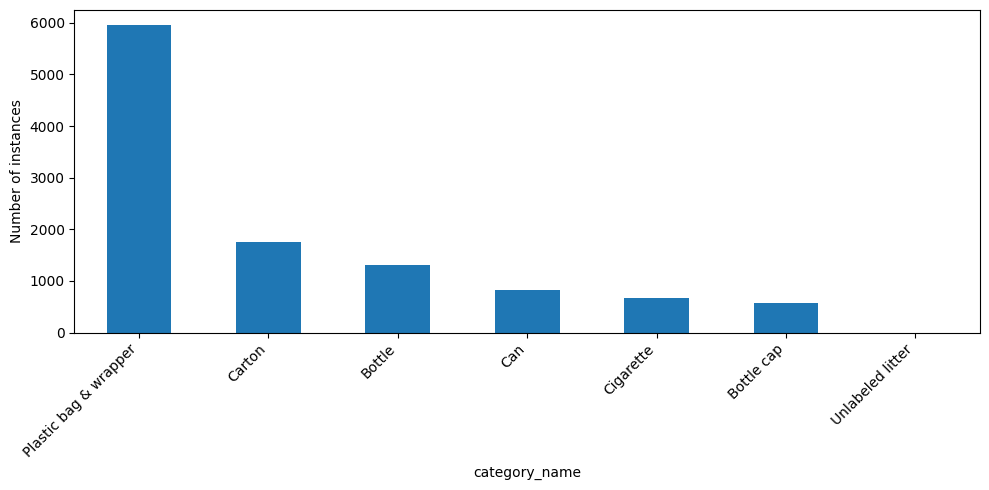

In [10]:
total_per_class.plot(
    x="category_name",
    y="num_instances",
    kind="bar",
    figsize=(10,5),
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of instances")
plt.tight_layout()
plt.show()


## subtask 2.2. zero-shot detection

In [11]:
#define dataloaders for each split
def collate_fn(batch): #standard collate function for object detection tasks provided in pytorch documentation
    return tuple(zip(*batch))
BATCH_SIZE = 4
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [12]:
#load models

from ultralytics import YOLO
from transformers import pipeline

yolo_model = YOLO('yolo11m.pt').to(device)
detr_model = pipeline('object-detection', model='facebook/detr-resnet-50',device=device)
rt_detr_model = pipeline('object-detection', model='PekingU/rtdetr_r50vd',device=device)

print(f'Models are on device: \nYOLO: {yolo_model.device}\nDETR device: {detr_model.device}\nRT-DETR device: {rt_detr_model.device}')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

Device set to use cuda


Models are on device: 
YOLO: cuda:0
DETR device: cuda
RT-DETR device: cuda


In [13]:
def dataset_to_torchmetrics(target):
    #convert coco annotations to torchmetrics format
    boxes = []
    labels = []
    for ann in target:
        box = ann['bbox']
        #coco format is [x_min, y_min, width, height], convert to [x_min, y_min, x_max, y_max]
        box = [box[0], box[1], box[0] + box[2], box[1] + box[3]]
        boxes.append(box)
        labels.append(0) #we don't consider classes, set all to 0
    return {'boxes': torch.tensor(boxes, dtype=torch.float32), 'labels': torch.tensor(labels, dtype=torch.int64)}

def yolo_to_torchmetrics(yolo_results, original_size, IMG_SIZE=640):
    yolo_boxes = yolo_results.boxes.xyxy
    # Rescale boxes to original image size
    yolo_boxes[:, [0, 2]] *= original_size[0] / IMG_SIZE
    yolo_boxes[:, [1, 3]] *= original_size[1] / IMG_SIZE
    return {
        "boxes": yolo_boxes,
        "scores": yolo_results.boxes.conf,
        "labels": torch.zeros(len(yolo_results.boxes.xyxy), dtype=torch.int64), # Ignoring class
    }

def detr_to_torchmetrics(detr_results, confidence_threshold=0.1):
    detr_results = [res for res in detr_results if res['score'] >= confidence_threshold]
    if len(detr_results) == 0:
        return {
            "boxes": torch.empty((0, 4), dtype=torch.float32),
            "scores": torch.empty((0,), dtype=torch.float32),
            "labels": torch.empty((0,), dtype=torch.int64), # Ignoring class
        }
    boxes = []
    scores = []
    for res in detr_results:
        box = res['box']
        if isinstance(box, dict):
            boxes.append([box['xmin'], box['ymin'], box['xmax'], box['ymax']])
        else:
            x,y,w,h = box
            boxes.append([x, y, x + w, y + h])
        scores.append(res['score'])
    return {
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "scores": torch.tensor(scores, dtype=torch.float32),
        "labels": torch.zeros(len(boxes), dtype=torch.int64), # Ignoring class
    }

In [14]:
def yolo_top_IoU(yolo_pred, target, n_boxes=10):
    # receive boxes predictions and target boxes for single image
    # select top-10 predictions based on confidence
    # for each target box compute IoU with 10 predictions
    # select prediction with highest IoU [delete from set]
    # final set of predictions is given to mAP
    top_indexes = torch.argsort(yolo_pred["scores"], descending=True)[:n_boxes]
    selected_boxes = yolo_pred["boxes"][top_indexes]
    selected_scores = yolo_pred["scores"][top_indexes]

    #ensure same device
        # selected_boxes = selected_boxes.to(device)
        # selected_scores = selected_scores.to(device)
        # target_boxes = target['boxes'].to(device)

    ious = torchvision.ops.box_iou(selected_boxes, target["boxes"])  # shape: (n_selected, n_target)
    matched_indexes = set()
    final_boxes = []
    final_scores = []

    for target_idx in range(ious.size(1)):
        available_indexes = [i for i in range(ious.size(0)) if i not in matched_indexes]
        if not available_indexes:
            break
        target_ious = ious[available_indexes, target_idx]
        best_iou_idx = available_indexes[torch.argmax(target_ious).item()]
        matched_indexes.add(best_iou_idx)
        final_boxes.append(selected_boxes[best_iou_idx].unsqueeze(0))
        final_scores.append(selected_scores[best_iou_idx].unsqueeze(0))

    return {
        "boxes": torch.cat(final_boxes, dim=0) if final_boxes else torch.empty((0,4), dtype=torch.float32),
        "scores": torch.cat(final_scores, dim=0) if final_scores else torch.empty((0,), dtype=torch.float32),
        "labels": torch.zeros(len(final_boxes), dtype=torch.int64), # Ignoring class
    }

def detr_top_IoU(detr_pred, target, n_boxes=10):
    # receive boxes predictions and target boxes for single image
    # select top-10 predictions based on confidence
    # for each target box compute IoU with 10 predictions
    # select prediction with highest IoU [delete from set]
    # final set of predictions is given to mAP

    top_indexes = torch.argsort(detr_pred['scores'], descending=True)[:n_boxes]
    selected_boxes = detr_pred['boxes'][top_indexes]
    selected_scores = detr_pred['scores'][top_indexes]

    ious = torchvision.ops.box_iou(selected_boxes, target['boxes'])  # shape: (n_selected, n_target)
    matched_indexes = set()
    final_boxes = []
    final_scores = []

    for target_idx in range(ious.size(1)):
        available_indexes = [i for i in range(ious.size(0)) if i not in matched_indexes]
        if not available_indexes:
            break
        target_ious = ious[available_indexes, target_idx]
        best_iou_idx = available_indexes[torch.argmax(target_ious).item()]
        matched_indexes.add(best_iou_idx)
        final_boxes.append(selected_boxes[best_iou_idx].unsqueeze(0))
        final_scores.append(selected_scores[best_iou_idx].unsqueeze(0))

    return {
        "boxes": torch.cat(final_boxes, dim=0) if final_boxes else torch.empty((0,4), dtype=torch.float32),
        "scores": torch.cat(final_scores, dim=0) if final_scores else torch.empty((0,), dtype=torch.float32),
        "labels": torch.zeros(len(final_boxes), dtype=torch.int64), # Ignoring class
    }

In [15]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
IMG_SIZE = 640
def evaluate_models(yolo_model, detr_model, rt_detr_model, data_loader,
                    yolo_conf=0.25, detr_conf=0.1, rt_detr_conf=0.1):


    metric_yolo = MeanAveragePrecision(class_metrics=False)
    metric_detr = MeanAveragePrecision(class_metrics=False)
    metric_rt_detr = MeanAveragePrecision(class_metrics=False)

    iou_metric_yolo = MeanAveragePrecision(class_metrics=False)
    iou_metric_detr = MeanAveragePrecision(class_metrics=False)
    iou_metric_rt_detr = MeanAveragePrecision(class_metrics=False)
    # yolo_confs = []
    # detr_scores = []
    # rt_detr_scores = []
    with torch.no_grad():
        for images, targets in data_loader:
            original_sizes = [img.size for img in images]  # Store original sizes for image rescaling
            yolo_batch = torch.stack(
                [torchvision.transforms.ToTensor()(
                    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE))(img))
                    for img in images]) #YOLO is happier with tensor [B,C,W,H], but doesn't handle resizing internally

            #YOLO inference
            yolo_results = yolo_model(yolo_batch, conf=yolo_conf, verbose=False)

            #DETR inference
            detr_batch = [img.convert("RGB") if img.mode != "RGB" else img for img in images] #DETR needs PIL RGB images
            detr_results = detr_model(detr_batch)
            #RT-DETR inference
            rt_detr_results = rt_detr_model(detr_batch)

            #transform target to map format
            targets = [dataset_to_torchmetrics(t) for t in targets]
            #yolo_results are the only one on device instead of cpu, move them
            yolo_results = [res.to('cpu') for res in yolo_results]
            #targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            #determine top k predictions for each model, where k is the number of ground truth boxes in the image
            for og_size,target,yolo_res,detr_res,rt_detr_res in zip(original_sizes,targets,yolo_results,detr_results,rt_detr_results):
                k = target["boxes"].shape[0]
                yolo_sorted_indices = torch.argsort(yolo_res.boxes.conf, descending=True)[:k]
                yolo_topk = yolo_res[yolo_sorted_indices]

                detr_topk = sorted(detr_res, key=lambda x: x['score'], reverse=True)[:k]
                rt_detr_topk = sorted(rt_detr_res, key=lambda x: x['score'], reverse=True)[:k]

                metric_yolo.update([yolo_to_torchmetrics(yolo_topk, og_size, IMG_SIZE)], [target])
                metric_detr.update([detr_to_torchmetrics(detr_topk, confidence_threshold=detr_conf)],[target])
                metric_rt_detr.update([detr_to_torchmetrics(rt_detr_topk, confidence_threshold=rt_detr_conf)],[target])


                # print(target['boxes'].device)
                # print(yolo_res.boxes.xyxy.device)
                # print(detr_to_torchmetrics(detr_res)['boxes'].device)

                iou_metric_yolo.update([yolo_top_IoU(yolo_to_torchmetrics(yolo_res, og_size, IMG_SIZE), target, n_boxes=10)], [target])
                iou_metric_detr.update([detr_top_IoU(detr_to_torchmetrics(detr_res, confidence_threshold=detr_conf), target, n_boxes=10)],[target])
                iou_metric_rt_detr.update([detr_top_IoU(detr_to_torchmetrics(rt_detr_res, confidence_threshold=rt_detr_conf), target, n_boxes=10)],[target])

    return metric_yolo.compute(), metric_detr.compute(), metric_rt_detr.compute(), iou_metric_yolo.compute(), iou_metric_detr.compute(), iou_metric_rt_detr.compute()


### We will now test each of the model for different tresholds [0.10, 0.25, 0.50, 0.75, 0.90]

In [16]:
def extract_scalar_metrics(metric_dict):
    keys = [
        "map", "map_50", "map_75",
        "map_small", "map_medium", "map_large",
        "mar_1", "mar_10", "mar_100",
        "mar_small", "mar_medium", "mar_large",
    ]
    out = {}
    for k in keys:
        if k in metric_dict:
            v = metric_dict[k]
            out[k] = v.item() if hasattr(v, "item") else float(v)
    return out


conf_thresholds = [0.10, 0.25, 0.50, 0.75, 0.90]

results_zero_shot = []

for conf in conf_thresholds:
    print(f"\n=== Evaluating zero-shot on TACO – conf = {conf} ===")

    yolo_map, detr_map, rt_detr_map, iou_yolo_map, iou_detr_map, iou_rt_detr_map = evaluate_models(
        yolo_model,
        detr_model,
        rt_detr_model,
        test_loader,
        yolo_conf=conf,
        detr_conf=conf,
        rt_detr_conf=conf,
    )

    results_zero_shot.append({
        "model": "YOLO",
        "selection": "top-k",
        "conf": conf,
        **extract_scalar_metrics(yolo_map),
    })
    results_zero_shot.append({
        "model": "DETR",
        "selection": "top-k",
        "conf": conf,
        **extract_scalar_metrics(detr_map),
    })
    results_zero_shot.append({
        "model": "RT-DETR",
        "selection": "top-k",
        "conf": conf,
        **extract_scalar_metrics(rt_detr_map),
    })

    results_zero_shot.append({
        "model": "YOLO",
        "selection": "IoU-top10",
        "conf": conf,
        **extract_scalar_metrics(iou_yolo_map),
    })
    results_zero_shot.append({
        "model": "DETR",
        "selection": "IoU-top10",
        "conf": conf,
        **extract_scalar_metrics(iou_detr_map),
    })
    results_zero_shot.append({
        "model": "RT-DETR",
        "selection": "IoU-top10",
        "conf": conf,
        **extract_scalar_metrics(iou_rt_detr_map),
    })

df_zero_shot = pd.DataFrame(results_zero_shot)
display(df_zero_shot.round(3))
df_zero_shot.to_csv("task2_zero_shot_taco_results.csv", index=False)



=== Evaluating zero-shot on TACO – conf = 0.1 ===


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



=== Evaluating zero-shot on TACO – conf = 0.25 ===

=== Evaluating zero-shot on TACO – conf = 0.5 ===

=== Evaluating zero-shot on TACO – conf = 0.75 ===

=== Evaluating zero-shot on TACO – conf = 0.9 ===


,model,selection,conf,map,map_50,map_75,map_small,map_medium,map_large,mar_1,mar_10,mar_100,mar_small,mar_medium,mar_large
0,YOLO,top-k,0.10,0.080,0.099,0.085,0.000,0.095,0.154,0.120,0.167,0.167,0.000,0.157,0.342
1,DETR,top-k,0.10,0.052,0.078,0.056,0.000,0.085,0.100,0.100,0.125,0.125,0.002,0.132,0.242
2,RT-DETR,top-k,0.10,0.060,0.072,0.062,0.003,0.099,0.094,0.101,0.120,0.120,0.005,0.140,0.215
3,YOLO,IoU-top10,0.10,0.108,0.133,0.115,0.000,0.111,0.217,0.136,0.192,0.192,0.000,0.175,0.399
4,DETR,IoU-top10,0.10,0.068,0.100,0.073,0.000,0.105,0.126,0.114,0.143,0.143,0.002,0.154,0.274
5,RT-DETR,IoU-top10,0.10,0.076,0.090,0.080,0.003,0.111,0.125,0.110,0.128,0.128,0.005,0.152,0.227
6,YOLO,top-k,0.25,0.061,0.073,0.065,0.000,0.065,0.124,0.095,0.118,0.118,0.000,0.091,0.259
7,DETR,top-k,0.25,0.052,0.078,0.056,0.000,0.085,0.100,0.100,0.125,0.125,0.002,0.132,0.242
8,RT-DETR,top-k,0.25,0.060,0.072,0.062,0.003,0.099,0.094,0.101,0.120,0.120,0.005,0.140,0.215
9,YOLO,IoU-top10,0.25,0.074,0.089,0.080,0.000,0.070,0.152,0.101,0.124,0.124,0.000,0.097,0.272


### below are some graphs to  better show the results obtained

Available columns: ['model', 'selection', 'conf', 'map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large', 'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large']


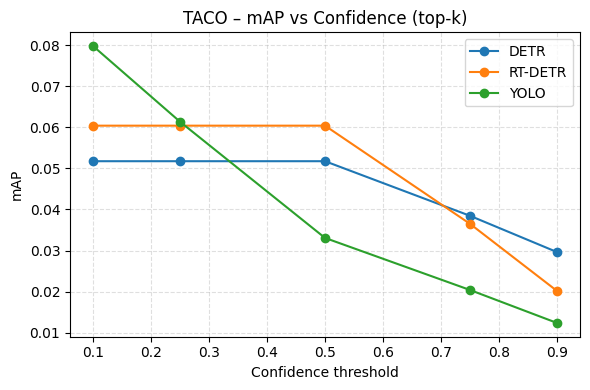

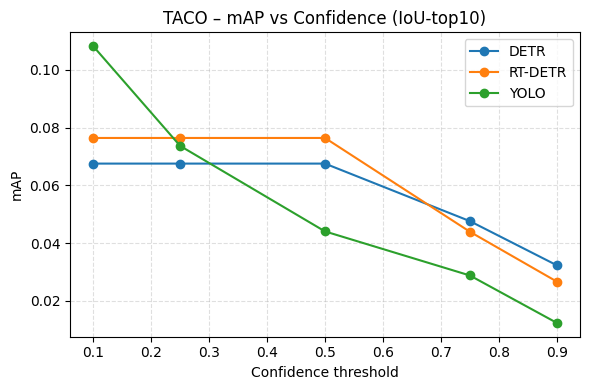

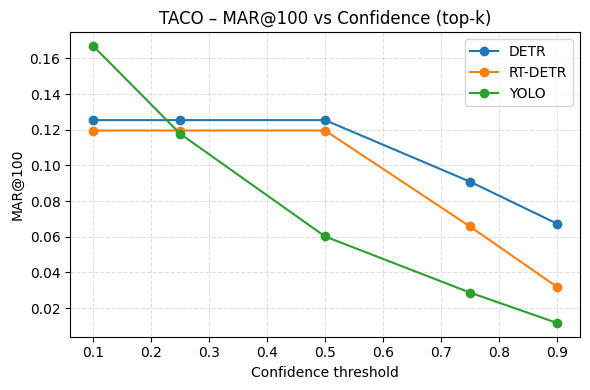

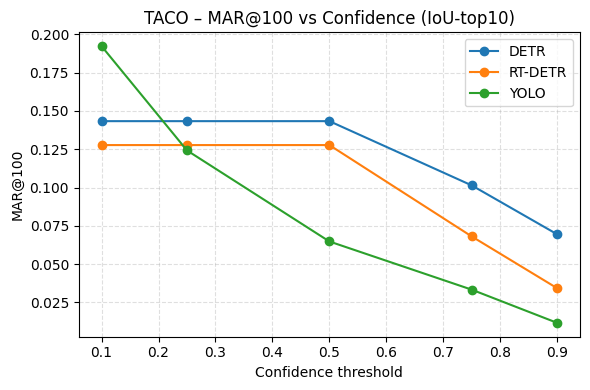

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and sort the dataset
df_zero_shot = pd.read_csv("task2_zero_shot_taco_results.csv")
df_zero_shot = df_zero_shot.sort_values(["model", "selection", "conf"]).reset_index(drop=True)

print("Available columns:", df_zero_shot.columns.tolist())

def plot_metric_vs_conf(df, metric_name, selection, title, ylabel):
    # Check whether the metric exists in the dataset
    if metric_name not in df.columns:
        print(f"[WARNING] Metric '{metric_name}' not found. "
              f"Available columns: {df.columns.tolist()}")
        return

    # Filter rows for the selected evaluation protocol
    subset = df[df["selection"] == selection]
    if subset.empty:
        print(f"[WARNING] No rows found for selection = '{selection}'.")
        return

    plt.figure(figsize=(6, 4))

    # Plot a curve for each model
    for model_name in subset["model"].unique():
        df_m = subset[subset["model"] == model_name]

        confs = df_m["conf"].values
        values = df_m[metric_name].values

        # Ensure points are ordered by confidence
        order = np.argsort(confs)
        confs = confs[order]
        values = values[order]

        plt.plot(confs, values, marker="o", label=model_name)

    plt.title(title)
    plt.xlabel("Confidence threshold")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------
#          VALID PLOTS
# -------------------------

# mAP (overall)
plot_metric_vs_conf(
    df_zero_shot,
    metric_name="map",
    selection="top-k",
    title="TACO – mAP vs Confidence (top-k)",
    ylabel="mAP"
)

plot_metric_vs_conf(
    df_zero_shot,
    metric_name="map",
    selection="IoU-top10",
    title="TACO – mAP vs Confidence (IoU-top10)",
    ylabel="mAP"
)

# MAR@100
plot_metric_vs_conf(
    df_zero_shot,
    metric_name="mar_100",
    selection="top-k",
    title="TACO – MAR@100 vs Confidence (top-k)",
    ylabel="MAR@100"
)

plot_metric_vs_conf(
    df_zero_shot,
    metric_name="mar_100",
    selection="IoU-top10",
    title="TACO – MAR@100 vs Confidence (IoU-top10)",
    ylabel="MAR@100"
)


The comparison in this experiment is consistent with Task 1: RT-DETR is overall the best-performing model, followed by DETR, and then YOLO.
As in Task 1, YOLO is actually the strongest only at confidence 0.10, where it briefly outperforms the transformer models. By 0.25, YOLO already drops to the same level as DETR and RT-DETR, and after that its mAP plunges much more sharply than in Task 1. This means YOLO deteriorates faster on the TACO dataset than it did on VOC.

DETR and RT-DETR instead remain relatively stable up to 0.50 and only start decreasing afterwards, with RT-DETR consistently ahead.

The difference between top-k and IoU-top10 is small and does not change the ranking of the models: the curves move slightly, but the behaviour and conclusions stay the same.

### Additional experiment: evaluating a second YOLO variant (YOLO-11s) at the baseline model’s optimal confidence to compare performance.

Best confidence for original YOLO (top-k): 0.1
YOLO size comparison at best confidence (top-k):


,model,selection,conf,map,map_50,map_75,map_small,map_medium,map_large,mar_1,mar_10,mar_100,mar_small,mar_medium,mar_large
0,YOLO-11m,top-k,0.1,0.080,0.099,0.085,0.0,0.095,0.154,0.120,0.167,0.167,0.0,0.157,0.342
1,YOLO-11s,top-k,0.1,0.069,0.085,0.072,0.0,0.081,0.131,0.101,0.151,0.151,0.0,0.119,0.329


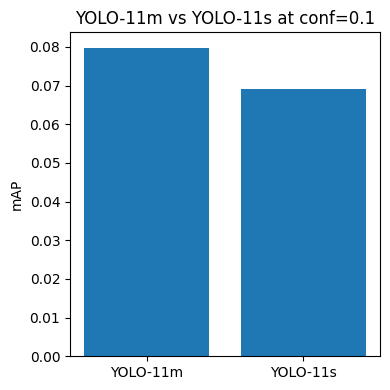

In [18]:
from ultralytics import YOLO

yolo_model_s = YOLO("yolo11s.pt").to(device)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# If needed, reload previous results
df_zero_shot = pd.read_csv("task2_zero_shot_taco_results.csv")

# pick best confidence for the original YOLO (top-k, based on mAP)
df_yolo_topk = df_zero_shot[
    (df_zero_shot["model"] == "YOLO") &
    (df_zero_shot["selection"] == "top-k")
]

best_row = df_yolo_topk.loc[df_yolo_topk["map"].idxmax()]
best_conf = float(best_row["conf"])

print("Best confidence for original YOLO (top-k):", best_conf)

# evaluate YOLO-11s at the same confidence
yolo_s_map, _, _, iou_yolo_s_map, _, _ = evaluate_models(
    yolo_model_s,
    detr_model,
    rt_detr_model,
    test_loader,
    yolo_conf=best_conf,
    detr_conf=best_conf,
    rt_detr_conf=best_conf,
)

yolo_s_metrics = extract_scalar_metrics(yolo_s_map)

# build direct comparison table YOLO-11m vs YOLO-11s (top-k, best_conf)
metric_cols = [c for c in df_zero_shot.columns if c not in ["model", "selection", "conf"]]

row_m = {
    "model": "YOLO-11m",
    "selection": "top-k",
    "conf": best_conf,
}
row_m.update({k: best_row[k] for k in metric_cols if k in best_row})

row_s = {
    "model": "YOLO-11s",
    "selection": "top-k",
    "conf": best_conf,
}
row_s.update(yolo_s_metrics)

df_yolo_size = pd.DataFrame([row_m, row_s])

print("YOLO size comparison at best confidence (top-k):")
display(df_yolo_size.round(3))

# simple bar plot for mAP comparison
plt.figure(figsize=(4, 4))
plt.bar(df_yolo_size["model"], df_yolo_size["map"])
plt.ylabel("mAP")
plt.title(f"YOLO-11m vs YOLO-11s at conf={best_conf}")
plt.tight_layout()
plt.show()



At the same confidence threshold (0.1), YOLO-11m performs slightly better than YOLO-11s across all main metrics.
The medium model achieves higher mAP (0.079 vs 0.070), mAP@50, and mAP@75, and also shows consistently higher mAP_medium and mAP_large.
Recall metrics (MAR@1, MAR@10, MAR@100) follow the same trend: YOLO-11m retrieves more correct objects on average.

Both models score 0 on small objects, indicating that neither variant is able to detect very small items in this zero-shot setting.

Overall, YOLO-11m is more reliable at low confidence, providing better precision and recall, while YOLO-11s is slightly weaker but still follows a similar behavior.

YOLO-11m performs better than YOLO-11s simply because it is a **bigger and stronger model**.
It has more layers and learns richer visual features, so it can recognize objects more reliably, especially in a complex dataset like TACO where items vary a lot in shape, texture, and lighting.
YOLO-11s is faster and lighter, but this comes at the cost of lower accuracy.



## Task 2.3. finetuning detr

In [35]:
from transformers import AutoImageProcessor
IMG_SIZE = 480 #we use a smaller image to avoid too heavy training, even though it means worse performance on small objects
checkpoint = "PekingU/rtdetr_v2_r50vd"


label2id = {'Plastic bag & wrapper': 0, #labels as defined in the updated dataset
  'Cigarette': 1,
  'Bottle': 2,
  'Bottle cap': 3,
  'Can': 4,
  'Carton': 5}

id2label = {v: k for k, v in label2id.items()}
label2id, id2label
categories = list(id2label.values())

image_processor = AutoImageProcessor.from_pretrained(
    checkpoint,
    do_resize=True,
    size={"height": IMG_SIZE, "width": IMG_SIZE},
    use_fast=True,
)


In [37]:
import albumentations as A

train_augmentation_and_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5), #randomly change light values of the image
        A.HueSaturationValue(p=0.1), #randomly change colors of the image by operating in the HSV space
        A.GaussianBlur(p=0.1),  #randomly add gaussian blur -> reduce quality of the image
        A.GaussNoise(p=0.1) #randomly add gaussian noise to the image
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True,
                            min_area=25,        # Discard boxes smaller than 5x5 pixels
                            min_visibility=0.1, # Discard boxes if <10% remains after cropping
                            filter_invalid_bboxes=True,
                            min_width=1,
                            min_height=1
                            ),
)

validation_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"],
                             clip=True,
                             min_visibility=0.1, # Discard boxes if <10% remains after cropping
                            filter_invalid_bboxes=True,
                            min_width=1,
                            min_height=1
                            ),
)

Augmentations randomly change color and light values of the images, occasionally adding noise and blur to incentivize the model into recognizing structure instead of single pixel values.

Other geometrical augmentations have been considered but for simplicity not included, like random warping of the image. This kind of augmentations could possibly worsen performance for the already struggling small boxes, so we opted out of them.

More sophisticated augmentations for this specific type of task include mosaicing and background mutations. The first one involves combining multiple images, while the second involves, among many possibilities, using masks to isolate the object and transfer it to another background, or mutating the background while maintaining the object. This was reedemed too complex to implement and possibly of little benefit for a pretrained model, as they would benefit more a model trained from zero.

In [38]:
#load datasets with provided custom dataset class

from taco_dataset import TACODETRDetectionDataset


train_dataset = TACODETRDetectionDataset(img_folder=root, ann_file=root+'/annotations_train.json',processor=image_processor, transform=train_augmentation_and_transform)
test_dataset = TACODETRDetectionDataset(img_folder=root, ann_file=root+'/annotations_test.json',processor=image_processor, transform= validation_transform)
val_dataset = TACODETRDetectionDataset(img_folder=root, ann_file=root+'/annotations_val.json',processor=image_processor, transform=validation_transform)

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (4, 4)
Categories shape: (4,)


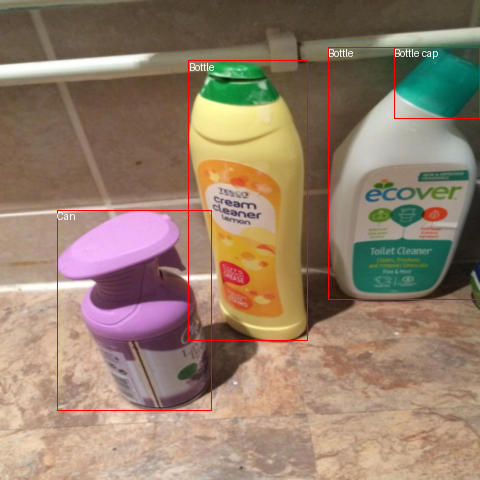

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (1, 4)
Categories shape: (1,)


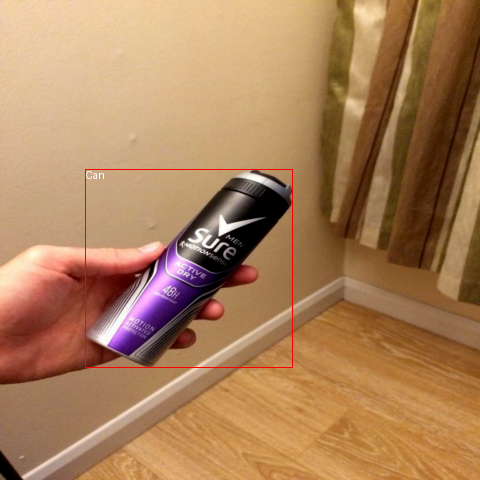

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (1, 4)
Categories shape: (1,)


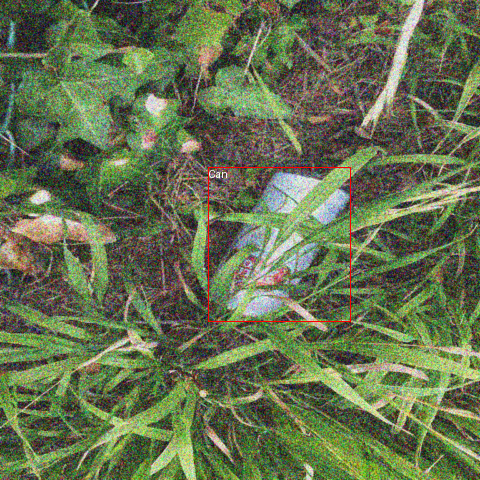

In [39]:
from PIL import Image, ImageDraw
for i in [15, 16, 17]:
    sample = train_dataset[i]

    # De-normalize image
    image = sample["pixel_values"]
    image = image.numpy().transpose(1, 2, 0)
    image = (image - image.min()) / (image.max() - image.min()) * 255.
    image = Image.fromarray(image.astype(np.uint8))

    # Convert boxes from [center_x, center_y, width, height] to [x, y, width, height] for visualization
    boxes = sample["labels"]["boxes"].numpy()
    boxes[:, :2] = boxes[:, :2] - boxes[:, 2:] / 2
    w, h = image.size
    boxes = boxes * np.array([w, h, w, h])[None]

    categories = sample["labels"]["class_labels"].numpy()
    # Draw boxes and labels on image
    draw = ImageDraw.Draw(image)
    for box, category in zip(boxes, categories):
        x, y, w, h = box
        draw.rectangle([x, y, x + w, y + h], outline="red", width=1)
        draw.text((x, y), id2label[category], fill="white")

    display(image)

In [40]:
from dataclasses import dataclass
from transformers.image_transforms import center_to_corners_format

@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor

class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label
    def collect_image_sizes(self,targets):
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x['size'] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes
    def collect_targets(self, targets, image_sizes):
        post_processed_targets=[]
        for target_batch, image_size_batch in zip(targets, image_sizes):
            batch_targets = []
            for target, size in zip(target_batch, image_size_batch):
                height, width = size
                boxes = torch.tensor(target['boxes'])
                boxes = center_to_corners_format(boxes)
                boxes = boxes * torch.tensor([width, height, width, height], dtype=torch.float32)

                labels = torch.tensor(target['class_labels'])
                post_processed_targets.append({'boxes': boxes, 'labels': labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")

        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = self.id2label[class_id.item()] if self.id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}
        return metrics


eval_compute_metrics_fn = MAPEvaluator(image_processor=image_processor, threshold=0.1, id2label=None)

In [41]:
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label= id2label,
    label2id= label2id,
    num_labels=len(id2label),
    ignore_mismatched_sizes=True,
)

Some weights of RTDetrV2ForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_v2_r50vd and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decod

In [42]:
from taco_dataset import taco_detr_collate_fn
collate_fn = taco_detr_collate_fn #use the provided collation function

In [43]:
#if you don't have / want to use wandb account, set it to offline mode
#os.environ['WANDB_MODE']= 'offline'

from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(
    output_dir=f"{checkpoint}-finetuned-taco", #saves model to PekingU/rtdetr...
    num_train_epochs=20,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=8,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    logging_strategy="steps",
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
    report_to="wandb",
    #report_to="none", #if you just don't want to use wandb
    fp16 = True #for colab T4 instance
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=image_processor,
    data_collator = collate_fn,
    compute_metrics = eval_compute_metrics_fn,
)


In [44]:
#wandb setup, comment this if you don't want to use wandb
import wandb
run = wandb.init(project="VisComp2025-Assignment2", name="RT-DETR-finetuned-on-TACO")


wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: luca-davi (luca-davi-universit-di-bologna) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [45]:
trainer.train()


Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map 0,Mar 100 0,Map 1,Mar 100 1,Map 2,Mar 100 2,Map 3,Mar 100 3,Map 4,Mar 100 4,Map 5,Mar 100 5
1,70.111900,39.156685,0.011000,0.015800,0.012100,0.006500,0.020100,0.019800,0.062800,0.158900,0.241800,0.083300,0.319700,0.429700,0.009200,0.310400,0.000100,0.035500,0.051700,0.452900,0.000100,0.078400,0.002800,0.340400,0.002500,0.233300
2,33.777900,21.046762,0.121800,0.149200,0.130100,0.095900,0.130000,0.418500,0.274100,0.429700,0.475100,0.281100,0.552400,0.872100,0.096200,0.448800,0.001200,0.072600,0.177500,0.655700,0.099600,0.335100,0.137800,0.702100,0.218400,0.636100
3,26.482100,16.291195,0.162700,0.207200,0.173900,0.078700,0.176500,0.301200,0.292400,0.424600,0.456100,0.251800,0.496000,0.645900,0.153800,0.501600,0.008600,0.077400,0.282500,0.631400,0.097000,0.370300,0.313800,0.661700,0.120500,0.494400
4,24.054700,14.627910,0.190700,0.239100,0.205000,0.079700,0.217700,0.528200,0.276100,0.385000,0.394600,0.211100,0.442100,0.668100,0.178300,0.449600,0.015700,0.111300,0.313800,0.554300,0.140400,0.335100,0.320500,0.489400,0.175600,0.427800
5,22.231300,14.028235,0.196400,0.253000,0.207900,0.080200,0.196500,0.399700,0.270500,0.371600,0.384200,0.236600,0.347900,0.563300,0.170900,0.364000,0.017600,0.108100,0.273800,0.431400,0.060100,0.278400,0.465500,0.642600,0.190400,0.480600
6,20.203700,13.390579,0.221600,0.280900,0.232900,0.073100,0.217000,0.651300,0.263400,0.350300,0.359500,0.161600,0.342300,0.796100,0.149000,0.314400,0.012000,0.069400,0.336600,0.498600,0.158800,0.302700,0.452300,0.600000,0.220600,0.372200
7,19.824600,13.112660,0.251900,0.324500,0.269100,0.097000,0.259300,0.673100,0.302400,0.402800,0.413400,0.228300,0.408300,0.794100,0.204900,0.421600,0.025100,0.104800,0.363100,0.507100,0.191700,0.324300,0.500600,0.625500,0.226100,0.497200
8,17.328900,13.276456,0.236600,0.306800,0.257800,0.107400,0.243300,0.628900,0.259900,0.357300,0.366200,0.253800,0.306000,0.728100,0.219800,0.375200,0.027800,0.106500,0.387200,0.510000,0.087800,0.243200,0.505000,0.651100,0.191800,0.311100
9,17.504300,13.336052,0.264400,0.330700,0.289100,0.106300,0.253300,0.711500,0.280200,0.386300,0.396200,0.238700,0.366100,0.783100,0.253000,0.367200,0.029400,0.125800,0.368600,0.440000,0.140800,0.286500,0.454800,0.646800,0.339600,0.511100
10,16.170800,13.007227,0.249700,0.321500,0.261700,0.119100,0.272500,0.620600,0.275100,0.345100,0.354300,0.193800,0.393100,0.691300,0.220800,0.325600,0.034800,0.104800,0.376600,0.444300,0.171000,0.270300,0.481000,0.589400,0.214100,0.391700


There were missing keys in the checkpoint model loaded: ['class_embed.0.weight', 'class_embed.0.bias', 'class_embed.1.weight', 'class_embed.1.bias', 'class_embed.2.weight', 'class_embed.2.bias', 'class_embed.3.weight', 'class_embed.3.bias', 'class_embed.4.weight', 'class_embed.4.bias', 'class_embed.5.weight', 'class_embed.5.bias', 'bbox_embed.0.layers.0.weight', 'bbox_embed.0.layers.0.bias', 'bbox_embed.0.layers.1.weight', 'bbox_embed.0.layers.1.bias', 'bbox_embed.0.layers.2.weight', 'bbox_embed.0.layers.2.bias', 'bbox_embed.1.layers.0.weight', 'bbox_embed.1.layers.0.bias', 'bbox_embed.1.layers.1.weight', 'bbox_embed.1.layers.1.bias', 'bbox_embed.1.layers.2.weight', 'bbox_embed.1.layers.2.bias', 'bbox_embed.2.layers.0.weight', 'bbox_embed.2.layers.0.bias', 'bbox_embed.2.layers.1.weight', 'bbox_embed.2.layers.1.bias', 'bbox_embed.2.layers.2.weight', 'bbox_embed.2.layers.2.bias', 'bbox_embed.3.layers.0.weight', 'bbox_embed.3.layers.0.bias', 'bbox_embed.3.layers.1.weight', 'bbox_embed.3.l

TrainOutput(global_step=2000, training_loss=27.629177658081055, metrics={'train_runtime': 1792.9021, 'train_samples_per_second': 8.913, 'train_steps_per_second': 1.116, 'total_flos': 2.83231120352256e+18, 'train_loss': 27.629177658081055, 'epoch': 20.0})

In [46]:
#if using wandb
run.finish()

eval/loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/map,▁▄▅▆▆▆▇▇█▇▇█▆██▇█▇██
eval/map_0,▁▃▅▆▆▅▇▇█▇█▇▆▇██▇██▇
eval/map_1,▁▁▂▃▄▃▅▅▆▆▇▄▆▆██▇▇▇▇
eval/map_2,▁▃▅▆▅▆▇▇▇▇██▆██▇▇▇▇▇
eval/map_3,▁▄▄▅▃▆▇▄▅▆▇█▆▇▇▅█▆▇▇
eval/map_4,▁▃▅▅▇▇██▇▇██▆▇█▆▇▇▇▇
eval/map_5,▁▅▃▅▅▆▆▅█▅▄▆▅▆▅▅▇▆▆▆
eval/map_50,▁▄▅▅▆▆▇▇▇▇▇█▆▇▇▇█▇▇▇
eval/map_75,▁▄▅▆▆▆▇▇█▇▇█▆▇█▇█▇█▇
+23,...


In [50]:

#save model as a wandb artifact, fallback to automatic local save
try:
  run = wandb.init(project="VisComp2025-Assignment2", name="RT-DETR-finetuned-on-TACO",id=run.id, resume="allow")

  # Folder where Trainer stored the best model
  best_dir = "rt_detr_taco_best"

  # 1. Save best model weights + processor to a folder
  trainer.model.save_pretrained(best_dir)
  image_processor.save_pretrained(best_dir)

  # 2. Create artifact
  artifact = wandb.Artifact(
      name="rtdetr_taco_best",
      type="model",
      description="Best RT-DETR model selected by eval_map",
  )

  # 3. Add the entire folder to the artifact
  artifact.add_dir(best_dir)

  # 4. Log artifact to W&B
  run.log_artifact(artifact)

  # 5. Optional: wait until upload finishes
  artifact.wait()

  run.finish()
except:
  print("wandb not available, model already saved locally")


wandb: Adding directory to artifact (rt_detr_taco_best)... Done. 6.8s


eval/loss,13.23995
eval/map,0.267
eval/map_0,0.2344
eval/map_1,0.0382
eval/map_2,0.3917
eval/map_3,0.2072
eval/map_4,0.4776
eval/map_5,0.2526
eval/map_50,0.3393
eval/map_75,0.2885
+28,...


['_step', '_runtime', 'train/loss', 'train/grad_norm', 'train/learning_rate', 'train/epoch', '_timestamp', 'train/global_step', 'eval/mar_10', 'eval/map', 'eval/map_4', 'eval/map_75', 'eval/map_2', 'eval/mar_1', 'eval/map_1', 'eval/map_small', 'eval/mar_small', 'eval/loss', 'eval/mar_100_2', 'eval/mar_100_1', 'eval/map_50', 'eval/map_5', 'eval/map_0', 'eval/map_3', 'eval/mar_100_5', 'eval/mar_100_0', 'eval/steps_per_second', 'eval/mar_medium', 'eval/samples_per_second', 'eval/map_large', 'eval/mar_large', 'eval/runtime', 'eval/mar_100_4', 'eval/map_medium', 'eval/mar_100', 'eval/mar_100_3']


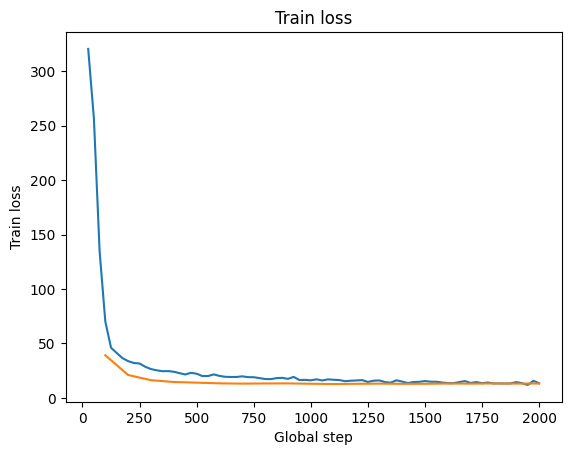

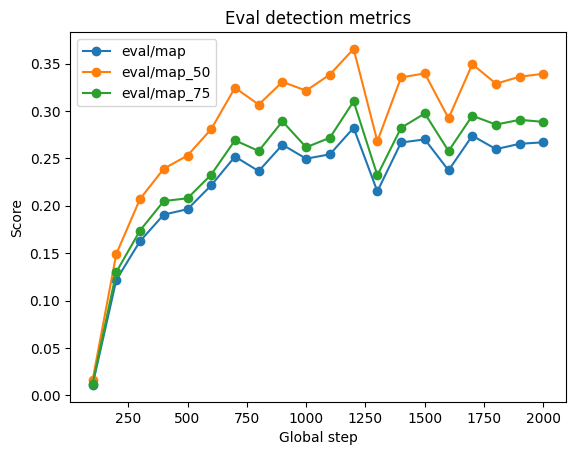

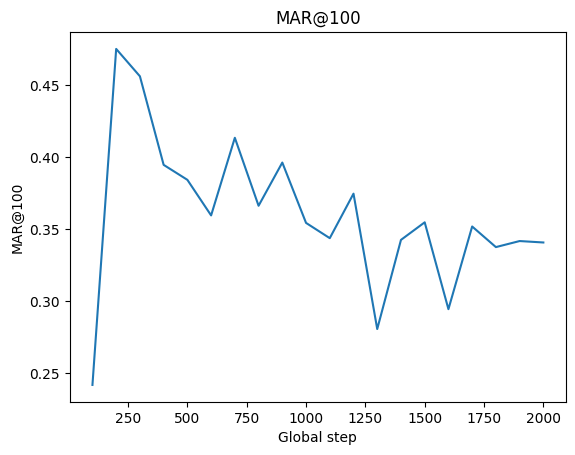

In [51]:
#use wandb to plot metrics

api = wandb.Api()


results = api.run(f"VisComp2025-Assignment2/runs/{run.id}").history(samples=None)
print(results.columns.tolist())

import matplotlib.pyplot as plt

step_col = "train/global_step"  # or "_step", both exist
train_col = "train/loss"
eval_col = "eval/loss"

train_hist = results[[step_col, train_col]].dropna()
eval_hist = results[[step_col, eval_col]].dropna()

plt.figure()
plt.plot(train_hist[step_col], train_hist[train_col])
plt.plot(eval_hist[step_col], eval_hist[eval_col])
plt.xlabel("Global step")
plt.ylabel("Train loss")
plt.title("Train loss")
plt.show()

metrics = ["eval/map", "eval/map_50", "eval/map_75"]

plt.figure()
for m in metrics:
    sub = results[[step_col, m]].dropna()
    plt.plot(sub[step_col], sub[m], marker="o", label=m)

plt.xlabel("Global step")
plt.ylabel("Score")
plt.title("Eval detection metrics")
plt.legend()
plt.show()

train_hist = results[[step_col,"eval/mar_100"]].dropna()
plt.figure()
plt.plot(train_hist[step_col], train_hist["eval/mar_100"])
plt.xlabel("Global step")
plt.ylabel("MAR@100")
plt.title("MAR@100")
plt.show()


In [52]:
#obtain epoch that generated best model

metric_col = "eval/map"
step_col = "_step"
idx = results[metric_col].idxmax()

row = results.loc[idx]

print("Best eval_map:", row[metric_col])
print("At epoch:", row.get("train/epoch"))
print("At step:", row.get("_step") or row.get("train/global_step"))
row

Best eval_map: 0.2823
At epoch: 12.0
At step: 59.0


,59
_step,5.900000e+01
_runtime,5.824124e-01
train/loss,NaN
train/grad_norm,NaN
train/learning_rate,NaN
train/epoch,1.200000e+01
_timestamp,1.764700e+09
train/global_step,1.200000e+03
eval/mar_10,3.661000e-01
eval/map,2.823000e-01


As for the training, we found out that around 20 epochs is the right amount of training needed, after which the loss curves plateau. As expected from fine-tuning a model, the first few epochs are the ones where the model learns the most, while for later epochs little learning is performed.
Judging merely the loss curves we can affirm that the model is learning strongly without overfitting as train and eval curves decrease and get very close. Overitting would manifest as an increase of eval loss while train loss keeps decreasing (the curves diverge), while underfitting would be indicated by a larger margin between the curves.

The best model was chosen using the best mAP obtained, for this run in particular it was in the 12th epoch, confirming that later epochs contribute less to the training process. This choice is further justified by the loss values, that around epoch 15 start oscillating indicating a plateau.

The mAP saturates at around 0.27, this can be justified by different factors: the pretrained model is a smal backbone, meaning it posses limited capacity, and the dataset is rather small, meaning that the model sees a limited amount of varied data and thus cannot learn any further.

By analyzing mAP per dimension of bounding box (small, medium, large) we encounter the same characteristics of zero-shot models: big objects are easier to detect, medium objects are learned well, but small objects are harder to detect and learn. The difficulty of learning small objects comes from multiple factors: the image is significantly compressed, dataset (being of reduced size) probably contains mostly big and medium objects. A solution for these problem would include using a bigger image size, a bigger backbone and a larger dataset. Augmentations focusing on small objects should also be considered.

If we analyze mAP based on single classes we notice they fluctuate, this can be explained again by the size of the dataset and by the skewed distribution of classes in the dataset (as shown in the earlier analysis). Overall almost all classes are underrepresented, and thus the model cannot learn them reliably.
We can compare performance on different classes, in particular the model learned better to recognize class 4 (Can) and worse class 1 (Cigarette). This can be justified through the size mAPs, we can consider the fact that cans are usually larger and easier to spot thanks to their peculiar shape and usual colorfulness, while cigarettes tend to be smaller, have a thinner silhouette, and blended with the background when thrown away.
Interestingly, class 0 (Plastic bag) is the most represented in the dataset, but is not the best learned, this again can be explained by the nature of plastic bag as trash as they assume many different silhouettes.

mAR can be seen as measuring the capacity of the model of just recognizing objects
[Marta check]
and is thightly coupled with the mAP metric. We can see that it shows a declining trend. This can be explained by the fact that the model becomes more selective and better at recognition, but starts becoming worse at detection as it learns. This can again be explained by the issues of the dataset size.


Overall we can confirm that, while the model is not perfect, it defenitely performs better than the zero-shot variants, obtaining much greater mAP on the data for which it's trained (as expected)


In [ ]:
#########################ALTERNATIVE DATA ANALYSIS USING CSV#################################

In [56]:
#if trainer was run using wandb, you have to run init
try:
  run = wandb.init(project="VisComp2025-Assignment2", name="RT-DETR-finetuned-on-TACO",id=run.id, resume="allow")
except:
  print("wandb not available")
# ====== Task 2.3 — Final evaluation on TACO TEST split ======
print("Evaluating the fine-tuned RT-DETR model on the TACO TEST set...")

test_metrics = trainer.evaluate(test_dataset)

# Round for readability
test_metrics_rounded = {k: round(float(v), 4) for k, v in test_metrics.items()}

print("Final Test Metrics:")
for k, v in test_metrics_rounded.items():
    print(f"{k}: {v}")

# Convert to a DataFrame (useful for report)
import pandas as pd
df_test_results = pd.DataFrame([test_metrics_rounded])

# Save to CSV
df_test_results.to_csv("task2_finetuned_rtdetr_test_results.csv", index=False)

print("\nSaved test results to task2_finetuned_rtdetr_test_results.csv")

try:
  run.finish()
except:
  print("wandb not available")


eval/loss,▁
eval/map,▁
eval/map_0,▁
eval/map_1,▁
eval/map_2,▁
eval/map_3,▁
eval/map_4,▁
eval/map_5,▁
eval/map_50,▁
eval/map_75,▁
+20,...


Evaluating the fine-tuned RT-DETR model on the TACO TEST set...


Final Test Metrics:
eval_loss: 13.857
eval_map: 0.2356
eval_map_50: 0.3088
eval_map_75: 0.2455
eval_map_small: 0.116
eval_map_medium: 0.2248
eval_map_large: 0.4748
eval_mar_1: 0.2718
eval_mar_10: 0.3551
eval_mar_100: 0.3551
eval_mar_small: 0.2192
eval_mar_medium: 0.3437
eval_mar_large: 0.5278
eval_map_0: 0.2332
eval_mar_100_0: 0.3081
eval_map_1: 0.0461
eval_mar_100_1: 0.091
eval_map_2: 0.2808
eval_mar_100_2: 0.3471
eval_map_3: 0.1804
eval_mar_100_3: 0.3032
eval_map_4: 0.333
eval_mar_100_4: 0.5653
eval_map_5: 0.3402
eval_mar_100_5: 0.5161
eval_runtime: 14.3921
eval_samples_per_second: 12.368
eval_steps_per_second: 1.598
epoch: 20.0

Saved test results to task2_finetuned_rtdetr_test_results.csv


eval/loss,▁
eval/map,▁
eval/map_0,▁
eval/map_1,▁
eval/map_2,▁
eval/map_3,▁
eval/map_4,▁
eval/map_5,▁
eval/map_50,▁
eval/map_75,▁
+20,...


inference on a single image

Detected Bottle with confidence 0.225 at location [197.21, 231.42, 352.69, 319.37]
Detected Bottle cap with confidence 0.142 at location [196.85, 231.36, 212.97, 244.64]


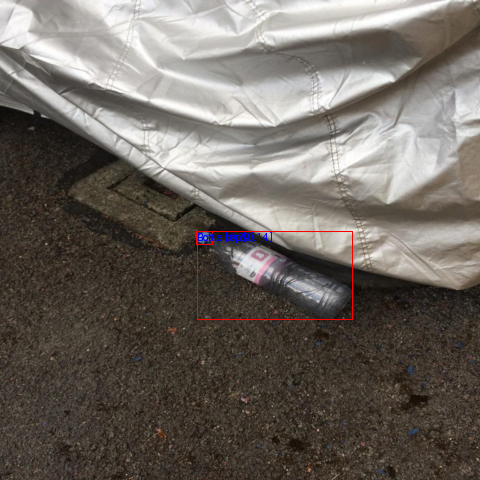

In [55]:

image_index = 2

# The model always expects a batch, so we need to collate our single sample into a batch
inputs = taco_detr_collate_fn([train_dataset[image_index]])
inputs = {k: ( v.to(device) if torch.is_tensor(v) else v) for k, v in inputs.items()}

inputs.pop("labels")  # Remove labels for inference
with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([(IMG_SIZE, IMG_SIZE)])

result = image_processor.post_process_object_detection(outputs,
                                                       threshold=0.1, # Confidence threshold
                                                       target_sizes=target_sizes)[0]

for score, label, box in zip(result["scores"], result["labels"], result["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )

image = inputs["pixel_values"][0].detach().cpu()
image_with_boxes = image.numpy().transpose(1, 2, 0)
image_with_boxes = (image_with_boxes - image_with_boxes.min()) / (image_with_boxes.max() - image_with_boxes.min()) * 255.
image_with_boxes = Image.fromarray(image_with_boxes.astype(np.uint8))

draw = ImageDraw.Draw(image_with_boxes)

for score, label, box in zip(result["scores"], result["labels"], result["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x, y, x2, y2 = tuple(box)
    draw.rectangle((x, y, x2, y2), outline="red", width=1)
    text_label = model.config.id2label[label.item()]
    draw.text((x, y), f"{text_label} [ {score.item():.2f} ]", fill="blue")

image_with_boxes

In [57]:
#for colab: zip and download the checkpoint
#locate best model folder on filesystem

PATH = "/content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200"

!zip -r /content/best_model.zip $PATH


  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/ (stored 0%)
  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/training_args.bin (deflated 53%)
  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/scheduler.pt (deflated 61%)
  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/trainer_state.json (deflated 80%)
  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/config.json (deflated 64%)
  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/scaler.pt (deflated 64%)
  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/model.safetensors (deflated 7%)
  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/preprocessor_config.json (deflated 53%)
  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/rng_state.pth (deflated 26%)
  adding: content/PekingU/rtdetr_v2_r50vd-finetuned-taco/checkpoint-1200/optimizer

In [59]:
#download the zip file

from google.colab import files
files.download('/content/best_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>